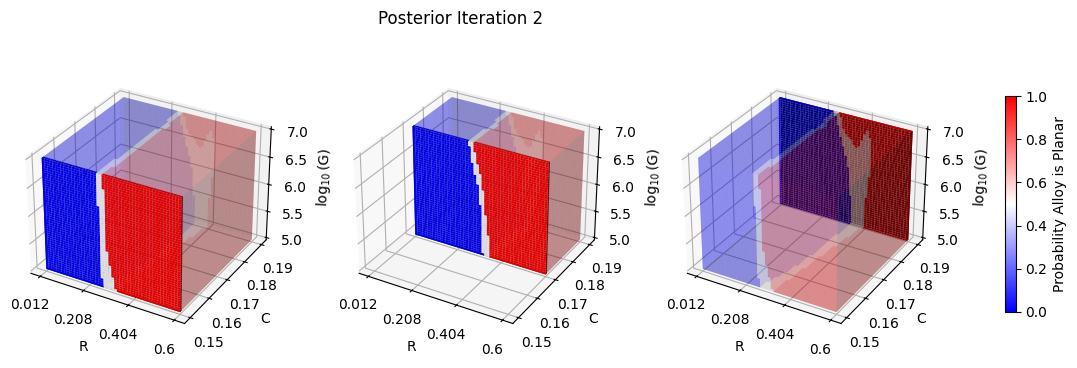

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# Function to map probability values to RGBA
cmap = mpl.colormaps['bwr']
def colorMap(p):
    return(np.array(cmap(int(255*p))))

# Read data, must have columns 'R','C','log10(G)', 'Predicted_Probability' or 'Prior' and be of shape (50,50,50)
df_grid = pd.read_csv('grid_df_iteration_2_3labels.csv')

# Sort by x, y, z
df_grid_sorted = df_grid.sort_values(by=['R','C','log10(G)'])

# Apply colormap function to all probability values and RGBA colors in a (50,50,50,4) array
#colorArray = np.stack(df_grid_sorted['Prior'].apply(colorMap).values).reshape(50,50,50,4)
#colorArray = np.stack(df_grid_sorted['Predicted_Probability'].apply(colorMap).values).reshape(50,50,50,4)
colorArray = np.stack(df_grid_sorted['Label_Probability'].apply(colorMap).values).reshape(50,50,50,4)

# Create copies and change A parameter (transparency) on desired planes
colorArray1 = colorArray.copy()
colorArray2 = colorArray.copy()
colorArray3 = colorArray.copy()

colorArray1[:,:,:,3] = 0.25
colorArray1[:,0,:,3] = 1
colorArray2[:,:,:,3] = 0.25
colorArray2[:,25,:,3] = 1
colorArray3[:,:,:,3] = 0.25
colorArray3[:,49,:,3] = 1

# Create voxel array, initialize with all true because all of them are going to be plotted
voxelarray = np.full((50, 50, 50), True)

# Create copies and remove desired voxels from each plot
voxelarray1 = voxelarray.copy()
voxelarray2 = voxelarray.copy()
voxelarray2[:,:25,:] = False
voxelarray3 = voxelarray.copy()
voxelarray3[:,:49,:] = False

# Create labels and select their respective ticks
numberRlabels = 4
numberClabels = 5
numberlogGlabels = 5

Rlabels = np.linspace(df_grid['R'].min(),df_grid['R'].max(),numberRlabels).round(3)
Rticks = np.linspace(0,50,numberRlabels)
Clabels = np.linspace(df_grid['C'].min(),df_grid['C'].max(),numberClabels).round(2)
Cticks = np.linspace(0,50,numberClabels)
logGlabels = np.linspace(df_grid['log10(G)'].min(),df_grid['log10(G)'].max(),numberlogGlabels).round(1)
logGticks = np.linspace(0,50,numberlogGlabels)

# Create figures and add subplots
fig = plt.figure(figsize=(12, 4))
ax1 = fig.add_subplot(1, 3, 1, projection='3d')
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
ax3 = fig.add_subplot(1, 3, 3, projection='3d')
ax4 = fig.add_subplot(1, 3, 3)

ax1.voxels(voxelarray1, facecolors=colorArray1)
ax1.set_xlabel('R')
ax1.set_ylabel('C')
ax1.set_zlabel(r'$\log_{10}$(G)')
ax1.set_xticks(ticks=Rticks,labels=Rlabels)
ax1.set_yticks(ticks=Cticks,labels=Clabels)
ax1.set_zticks(ticks=logGticks,labels=logGlabels)

ax2.voxels(voxelarray2, facecolors=colorArray2)
ax2.set_xlabel('R')
ax2.set_ylabel('C')
ax2.set_zlabel(r'$\log_{10}$(G)')
ax2.set_xticks(ticks=Rticks,labels=Rlabels)
ax2.set_yticks(ticks=Cticks,labels=Clabels)
ax2.set_zticks(ticks=logGticks,labels=logGlabels)

ax3.voxels(voxelarray1, facecolors=colorArray3)
ax3.set_xlabel('R')
ax3.set_ylabel('C')
ax3.set_zlabel(r'$\log_{10}$(G)')
ax3.set_xticks(ticks=Rticks,labels=Rlabels)
ax3.set_yticks(ticks=Cticks,labels=Clabels)
ax3.set_zticks(ticks=logGticks,labels=logGlabels)

ax4.axis('off')
norm = mpl.colors.Normalize(vmin=0, vmax=1)
sm = plt.cm.ScalarMappable(cmap='bwr', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm,ax=ax4,shrink=0.7,anchor=(3.5,0.5))
cbar.set_label('Probability Alloy is Planar')

fig.suptitle('Posterior Iteration 2')

plt.show()